# Laboratorio · Simulador (Fase 1) — cortes mensuales

Banco de pruebas de `src/tesis/simulador/`. Genera un flujo de **cortes mensuales**
(cada período = un lote nuevo de solicitantes), inyecta deterioro controlado, y lo
visualiza. Retardo de etiquetas por defecto = **12 meses** (coherente con la ventana
de desempeño M2–M13 de la `VarDep`).

Kernel: **Python (tesis-pr196)**. Edita la celda del **plan** y re-corre.

## 0. Setup

In [12]:
import sys
from pathlib import Path

def _raiz(inicio: Path) -> Path:
    for d in [inicio, *inicio.parents]:
        if (d / 'src' / 'tesis' / 'modelo_base.py').exists():
            return d
    raise RuntimeError(f'No encuentro la raíz desde {inicio}')

ROOT = _raiz(Path.cwd())
if str(ROOT / 'src') not in sys.path:
    sys.path.insert(0, str(ROOT / 'src'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score

from tesis.simulador.poblacion import cargar_poblacion
from tesis.simulador import drift
from tesis.simulador.simulador import (
    Simulador, ConfigSimulacion, plan_sano, agregar_episodio)
from tesis.modelo_base import ModeloBase
print('ROOT =', ROOT)

ROOT = /Users/duck/Documents/Maestría/TESIS


## 1. Cargar el *pool* y el modelo base

In [13]:
# Pool = cohorte TEST_OOT (2022-09), que el modelo NO entrenó → sin fuga de datos
from tesis.simulador.poblacion import COHORTE_OOT
pool = cargar_poblacion(ruta=ROOT / 'data' / 'buro' / 'InfoModelamiento.pkl', cohorte=COHORTE_OOT)
mb = ModeloBase.cargar(ROOT / 'models' / 'modelo_base.pkl')
print('pool (TEST_OOT):', pool.shape, '· bad-rate =', round(pool['VarDep'].mean(), 3))
print('modelo base:', len(mb.seleccion), 'features · C =', round(mb.metadata['C'], 6))

pool (TEST_OOT): (9697, 2506) · bad-rate = 0.444
modelo base: 18 features · C = 0.006158


## 2. Helpers: PSI y marcas de deterioro

In [14]:
def psi(base, actual, bins=10):
    cortes = np.unique(np.quantile(base, np.linspace(0, 1, bins + 1)))
    def prop(x):
        c = pd.Series(pd.cut(x, cortes, include_lowest=True)).value_counts().sort_index()
        return (c / c.sum()).clip(lower=1e-6)
    e, a = prop(base), prop(actual)
    return float(((a - e) * np.log(a / e)).sum())

def marcas_drift(hist):
    """Períodos donde ARRANCA un episodio de deterioro (cambia el tipo)."""
    marcas = []
    prev = 'sano'
    for _, r in hist.iterrows():
        if r.tipo != 'sano' and r.tipo != prev:
            marcas.append((int(r.periodo), r.fecha, r.tipo))
        prev = r.tipo
    return marcas

COLORES = {'covariate_shift': '#e76f51', 'concept_drift': '#8338ec',
           'mezcla_poblacional': '#3a86ff'}

def dibujar_marcas(ax, marcas, y_texto=None):
    for p, f, tipo in marcas:
        ax.axvline(p, color=COLORES.get(tipo, 'k'), ls='--', lw=1.6, alpha=0.9)
        yt = ax.get_ylim()[1] if y_texto is None else y_texto
        ax.text(p + 0.2, yt, f'{tipo}\n{f:%Y-%m}', color=COLORES.get(tipo, 'k'),
                fontsize=8, va='top')

## 3. Firmas de los inyectores de drift
Un lote sano vs cada drift a intensidad máxima. Cada mecanismo deja una huella distinta.

In [15]:
N = 3000
rng0 = np.random.default_rng(7)
sano = drift.muestra_sana(pool, N, rng0)
p_sano = mb.score_malo(sano)
feat_sano = sano['MAX_DVEN_SCE_6M'].to_numpy()
filas = [{'drift': 'sano', 'bad_rate': sano['VarDep'].mean(),
          'AUC_real': roc_auc_score(sano['VarDep'], p_sano), 'PSI_score': 0.0, 'PSI_feat': 0.0}]
for nombre in ['covariate_shift', 'concept_drift', 'mezcla_poblacional']:
    b = drift.INYECTORES[nombre](pool, N, np.random.default_rng(7), 1.0)
    p = mb.score_malo(b)
    filas.append({'drift': nombre, 'bad_rate': b['VarDep'].mean(),
                  'AUC_real': roc_auc_score(b['VarDep'], p),
                  'PSI_score': psi(p_sano, p),
                  'PSI_feat': psi(feat_sano, b['MAX_DVEN_SCE_6M'].to_numpy())})
pd.DataFrame(filas).set_index('drift').round(3)

,bad_rate,AUC_real,PSI_score,PSI_feat
drift,,,,
sano,0.450,0.883,0.000,0.000
covariate_shift,0.554,0.904,0.101,0.066
concept_drift,0.450,0.745,0.000,0.000
mezcla_poblacional,0.794,0.891,0.238,0.128


## 4. Plan mensual  ← *la celda que tocas*
Define la línea de tiempo: nº de meses, tamaño del corte, retardo (meses), fecha de
inicio, y los episodios de drift. Por defecto: un **covariate shift** (visible en las
distribuciones) y un **concept drift** (invisible en distribuciones, pero hunde el AUC).

In [16]:
cfg = ConfigSimulacion(n_periodos=24, tam_lote=1500, retardo_periodos=12,
                       fecha_inicio='2022-10-31', frecuencia='ME', semilla=42)

plan = plan_sano(cfg.n_periodos)
agregar_episodio(plan, 'covariate_shift', inicio=6,  fin=10, intensidad=0.8, forma='escalon')
agregar_episodio(plan, 'concept_drift',   inicio=14, fin=20, intensidad=1.0, forma='rampa')

sim = Simulador(pool, cfg, plan)
gt = sim.ground_truth()
gt[gt.tipo != 'sano']

,periodo,fecha,tipo,intensidad
6,6,2023-04-30,covariate_shift,0.8000
7,7,2023-05-31,covariate_shift,0.8000
8,8,2023-06-30,covariate_shift,0.8000
9,9,2023-07-31,covariate_shift,0.8000
14,14,2023-12-31,concept_drift,0.1667
15,15,2024-01-31,concept_drift,0.3333
16,16,2024-02-29,concept_drift,0.5000
17,17,2024-03-31,concept_drift,0.6667
18,18,2024-04-30,concept_drift,0.8333
19,19,2024-05-31,concept_drift,1.0000


## 5. Correr el stream y recolectar
Para cada mes: el modelo puntúa, calculamos el oráculo (AUC/bad-rate reales) y los PSI,
y guardamos los **scores** y una **variable continua** del lote para las distribuciones.

In [17]:
VAR_CONT = 'MAX_DVEN_SCE_6M'   # variable continua a inspeccionar (cámbiala)

registros, scores_mes, var_mes = [], [], []
for lote in sim.stream():
    p = mb.score_malo(lote.features)
    scores_mes.append(p)
    var_mes.append(lote.features[VAR_CONT].to_numpy())
    registros.append({
        'periodo': lote.periodo, 'fecha': lote.fecha, 'tipo': lote.espec.tipo,
        'intensidad': lote.espec.intensidad,
        'bad_rate': float(lote.features['VarDep'].mean()),
        'AUC_real': roc_auc_score(lote.features['VarDep'], p),
        'PSI_score': psi(p_sano, p),
        'PSI_feat': psi(feat_sano, lote.features[VAR_CONT].to_numpy()),
        'score_medio': float(p.mean()), 'periodo_revelado': lote.periodo_revelado,
    })
hist = pd.DataFrame(registros)
hist['AUC_observable'] = hist['AUC_real'].shift(cfg.retardo_periodos)
marcas = marcas_drift(hist)
xt = list(range(0, cfg.n_periodos, 3))
xlab = [hist.fecha.iloc[i].strftime('%Y-%m') for i in xt]
print('marcas de deterioro:', [(p, f'{f:%Y-%m}', t) for p, f, t in marcas])
hist[['periodo','fecha','tipo','intensidad','bad_rate','AUC_real','PSI_score','PSI_feat']].round(3)

marcas de deterioro: [(6, '2023-04', 'covariate_shift'), (14, '2023-12', 'concept_drift')]


/var/folders/v6/d_4300n96432y2g47c2hlw640000gn/T/ipykernel_2619/703941708.py:23: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  hist[['periodo','fecha','tipo','intensidad','bad_rate','AUC_real','PSI_score','PSI_feat']].round(3)


,periodo,fecha,tipo,intensidad,bad_rate,AUC_real,PSI_score,PSI_feat
0,0,2022-10-31,sano,0.000,0.437,0.898,0.006,0.003
1,1,2022-11-30,sano,0.000,0.444,0.892,0.009,0.001
2,2,2022-12-31,sano,0.000,0.465,0.885,0.015,0.005
3,3,2023-01-31,sano,0.000,0.445,0.890,0.016,0.004
4,4,2023-02-28,sano,0.000,0.467,0.878,0.004,0.001
5,5,2023-03-31,sano,0.000,0.436,0.894,0.007,0.002
6,6,2023-04-30,covariate_shift,0.800,0.532,0.897,0.071,0.048
7,7,2023-05-31,covariate_shift,0.800,0.515,0.906,0.042,0.035
8,8,2023-06-30,covariate_shift,0.800,0.520,0.886,0.045,0.037
9,9,2023-07-31,covariate_shift,0.800,0.529,0.878,0.070,0.045


## 6. Línea de tiempo — verdad completa + zona ciega

Cada punto de AUC va en **el mes de su cohorte** (su lugar real). Parado en un mes
`mes_hoy`, los últimos `retardo_periodos` meses **aún no tienen etiquetas maduras**:
esa **zona ciega** (roja) es la parte de la verdad que el agente todavía NO puede medir.
Mueve `mes_hoy` y verás la frontera avanzar. La línea sólida = lo que el agente ya
conoce; la punteada gris = lo que sigue madurando.

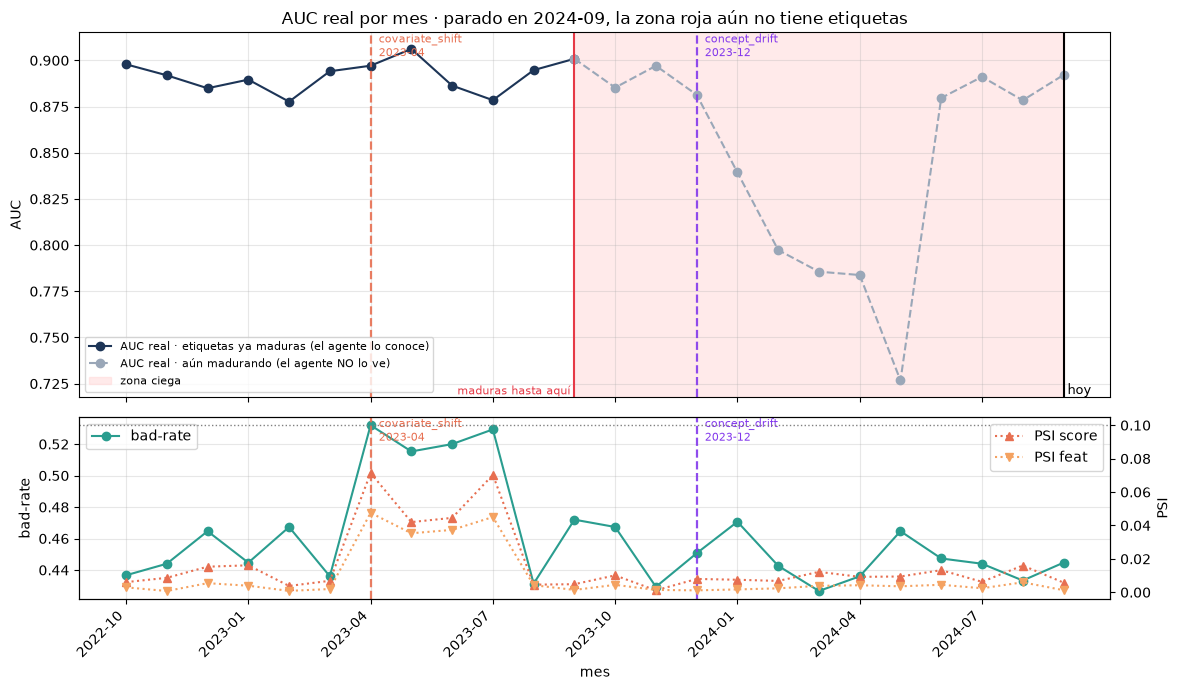

In [18]:
# ¿En qué mes estás parado 'hoy'?  (cámbialo para mover la frontera)
mes_hoy = cfg.n_periodos - 1
frontera = mes_hoy - cfg.retardo_periodos   # etiquetas maduras solo hasta aquí

fig, (a1, a2) = plt.subplots(2, 1, figsize=(12, 7), sharex=True,
                             gridspec_kw={'height_ratios': [2, 1]})

# AUC real, cada punto en SU mes. Sólido = ya maduró (agente lo conoce); punteado = pendiente
conocido  = hist[hist.periodo <= frontera]
pendiente = hist[hist.periodo >= frontera]
a1.plot(conocido.periodo, conocido.AUC_real, 'o-', color='#1d3557',
        label='AUC real · etiquetas ya maduras (el agente lo conoce)')
a1.plot(pendiente.periodo, pendiente.AUC_real, 'o--', color='#9aa7b8',
        label='AUC real · aún madurando (el agente NO lo ve)')
if frontera < mes_hoy:
    a1.axvspan(frontera, mes_hoy, color='#ffd6d6', alpha=0.5, label='zona ciega')
a1.axvline(frontera, color='#e63946', lw=1.5)
a1.axvline(mes_hoy, color='k', lw=1.5)
y0 = a1.get_ylim()[0]
a1.text(mes_hoy, y0, ' hoy', color='k', va='bottom', ha='left', fontsize=9)
a1.text(frontera, y0, 'maduras hasta aquí ', color='#e63946', va='bottom', ha='right', fontsize=8)
a1.set_ylabel('AUC'); a1.legend(loc='lower left', fontsize=8); a1.grid(alpha=0.3)
a1.set_title(f'AUC real por mes · parado en {hist.fecha.iloc[mes_hoy]:%Y-%m}, la zona roja aún no tiene etiquetas')
dibujar_marcas(a1, marcas)

# Panel 2: bad-rate y PSI (señales SÍ disponibles cada mes, sin esperar etiquetas)
a2.plot(hist.periodo, hist.bad_rate, 'o-', color='#2a9d8f', label='bad-rate')
a2b = a2.twinx()
a2b.plot(hist.periodo, hist.PSI_score, '^:', color='#e76f51', label='PSI score')
a2b.plot(hist.periodo, hist.PSI_feat, 'v:', color='#f4a261', label='PSI feat')
a2b.axhline(0.10, color='gray', ls=':', lw=1)
a2.set_ylabel('bad-rate'); a2b.set_ylabel('PSI'); a2.set_xlabel('mes')
a2.set_xticks(xt); a2.set_xticklabels(xlab, rotation=45, ha='right')
a2.legend(loc='upper left'); a2b.legend(loc='upper right'); a2.grid(alpha=0.3)
dibujar_marcas(a2, marcas, y_texto=a2.get_ylim()[1])
plt.tight_layout(); plt.show()

## 7. Densidad del **score** en el tiempo
Mapa de calor: cada columna es un mes, el color es la densidad de P(malo). Fíjate:
con **covariate shift** la masa se desplaza a la derecha; con **concept drift** casi no
se mueve (por eso monitorear solo el score se le escapa).

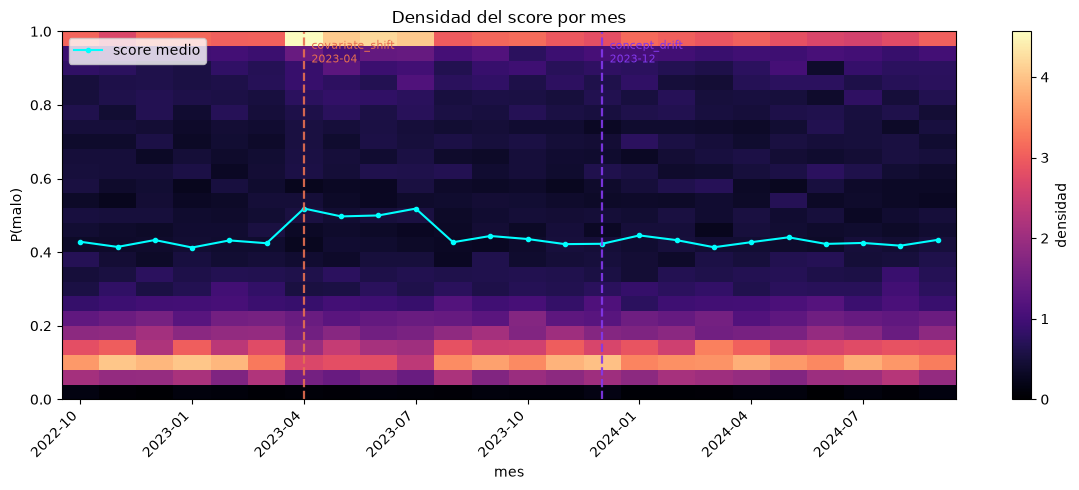

In [19]:
bins_s = np.linspace(0, 1, 26)
M = np.column_stack([np.histogram(s, bins=bins_s, density=True)[0] for s in scores_mes])
fig, ax = plt.subplots(figsize=(12, 5))
im = ax.imshow(M, aspect='auto', origin='lower', cmap='magma',
               extent=[-0.5, cfg.n_periodos - 0.5, 0, 1])
ax.plot(hist.periodo, hist.score_medio, 'o-', color='cyan', lw=1.5, ms=3, label='score medio')
ax.set_ylabel('P(malo)'); ax.set_xlabel('mes'); ax.set_title('Densidad del score por mes')
ax.set_xticks(xt); ax.set_xticklabels(xlab, rotation=45, ha='right')
fig.colorbar(im, ax=ax, label='densidad'); ax.legend(loc='upper left')
dibujar_marcas(ax, marcas, y_texto=0.98)
plt.tight_layout(); plt.show()

## 8. Distribución de una **variable continua** en el tiempo
Misma idea para `VAR_CONT`. Buckets fijados en el período base (percentiles); cada
columna muestra qué **proporción** del lote cae en cada bucket ese mes. El covariate
shift empuja masa hacia los buckets altos (más mora).

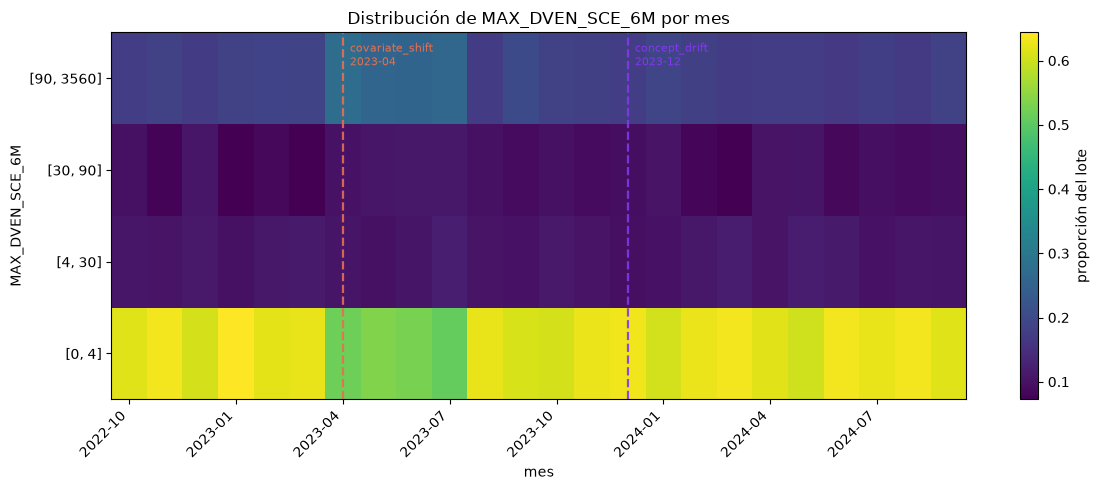

In [20]:
nb = 8
base_vals = np.concatenate([var_mes[i] for i in hist[hist.tipo=='sano'].periodo[:6]])
edges = np.unique(np.quantile(base_vals, np.linspace(0, 1, nb + 1)))
etq = [f'[{edges[i]:.0f}, {edges[i+1]:.0f}]' for i in range(len(edges)-1)]
def shares(x):
    idx = np.clip(np.digitize(x, edges[1:-1]), 0, len(edges)-2)
    return np.bincount(idx, minlength=len(edges)-1) / len(x)
S = np.column_stack([shares(v) for v in var_mes])
fig, ax = plt.subplots(figsize=(12, 5))
im = ax.imshow(S, aspect='auto', origin='lower', cmap='viridis',
               extent=[-0.5, cfg.n_periodos - 0.5, -0.5, len(etq)-0.5])
ax.set_yticks(range(len(etq))); ax.set_yticklabels(etq)
ax.set_xlabel('mes'); ax.set_ylabel(VAR_CONT); ax.set_title(f'Distribución de {VAR_CONT} por mes')
ax.set_xticks(xt); ax.set_xticklabels(xlab, rotation=45, ha='right')
fig.colorbar(im, ax=ax, label='proporción del lote')
dibujar_marcas(ax, marcas, y_texto=len(etq)-0.6)
plt.tight_layout(); plt.show()

## 9. Bucketización en el tiempo (composición apilada)
La misma bucketización de `VAR_CONT`, pero como áreas apiladas: se ve cómo la mezcla de
buckets se deforma mes a mes. Las líneas verticales marcan el inicio de cada deterioro.

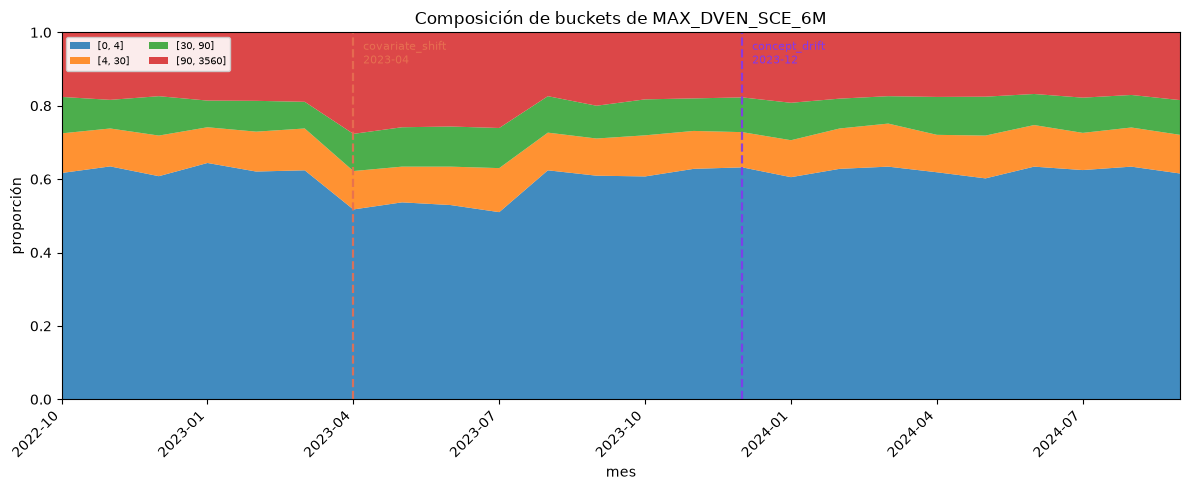

In [21]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.stackplot(hist.periodo, S, labels=etq, alpha=0.85)
ax.set_xlim(0, cfg.n_periodos - 1); ax.set_ylim(0, 1)
ax.set_xlabel('mes'); ax.set_ylabel('proporción'); ax.set_title(f'Composición de buckets de {VAR_CONT}')
ax.set_xticks(xt); ax.set_xticklabels(xlab, rotation=45, ha='right')
ax.legend(loc='upper left', fontsize=7, ncol=2, framealpha=0.9)
dibujar_marcas(ax, marcas, y_texto=0.98)
plt.tight_layout(); plt.show()

## 10. Experimenta
- Sube `retardo_periodos` → el hueco AUC real vs observable crece.
- Cambia `VAR_CONT` por otra continua (`SALDO_PROMEDIO_AHORRO`, `INGRESOS`, …).
- Usa `mezcla_poblacional` → verás el bad-rate dispararse; `concept_drift` → AUC cae sin
  mover las distribuciones.
- `forma='escalon'` vs `'rampa'`; solapa episodios; cambia la `semilla`.

Cuando te haga clic, seguimos con la **Fase 2 (señales)** — lo que el agente verá para decidir.